# EDA — Corpus de licitações ComprasNet DF 2025

Análise exploratória do corpus `data/processed/licitacoes_corpus.jsonl` (423 editais).
Objetivos: entender a distribuição das **macroáreas** (label da classificação), de
modalidade/tipo, o **tamanho dos textos**, o **valor homologado** por área e checar o
**vazamento de label** discutido no guia (§6.1).

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

# Permite importar src.* ao rodar o notebook de dentro de notebooks/.
ROOT = Path.cwd()
if (ROOT / "src").exists():
    pass
elif (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.preprocess.labels import AREAS, area_for_orgao, normalize

CORPUS = ROOT / "data" / "processed" / "licitacoes_corpus.jsonl"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

records = []
with CORPUS.open(encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            r = json.loads(line)
            r["area"] = area_for_orgao(r.get("orgao_csv", ""))
            records.append(r)

print(f"{len(records)} editais carregados")
print("Campos:", list(records[0].keys()))

423 editais carregados
Campos: ['id', 'numero_licitacao', 'modalidade', 'situacao', 'orgao_csv', 'orgao_html', 'tipo', 'objeto_csv', 'objeto_html', 'total_homologado', 'edital_url', 'texto', 'num_caracteres', 'num_itens', 'area']


## 1. Distribuição das areas macros (label)

O label é derivado do órgão (`orgao_csv`) por palavras-chave — ver `src/preprocess/labels.py`.

 112  Saude
  49  Saneamento
  58  Seguranca
  17  Educacao
  24  Infraestrutura/Obras
 163  Administracao/Outros


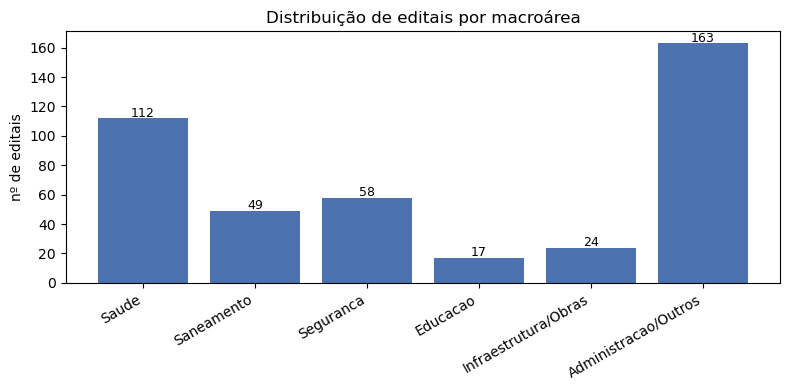

In [7]:
area_counts = Counter(r["area"] for r in records)
ordered = [(a, area_counts.get(a, 0)) for a in AREAS]
for a, n in ordered:
    print(f"{n:4d}  {a}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([a for a, _ in ordered], [n for _, n in ordered], color="#4C72B0")
ax.set_ylabel("nº de editais")
ax.set_title("Distribuição de editais por macroárea")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
for i, (_, n) in enumerate(ordered):
    ax.text(i, n + 1, str(n), ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "eda_areas.png", dpi=120)
plt.show()

> Classes muito **desbalanceadas**: Administração/Outros e Saúde dominam; Educação (17) e
> Infraestrutura (24) são minoritárias — esperar F1 instável nelas (documentar na discussão).

## 2. Modalidade e tipo de contratação

In [3]:
for campo in ("modalidade", "tipo"):
    print(f"--- {campo} ---")
    for valor, n in Counter(r.get(campo, "") for r in records).most_common():
        print(f"  {n:4d}  {valor}")
    print()

--- modalidade ---
   278  PREGÃO
   134  DISPENSA DE LICITAÇÃO
    11  CONCORRÊNCIA

--- tipo ---
   320  MATERIAL
   103  SERVIÇO



## 3. Tamanho dos textos (em palavras)

min=9  mediana=239  max=5524
acima de 512 palavras: 114 editais (relevante para o truncamento do BERT em 512 tokens)


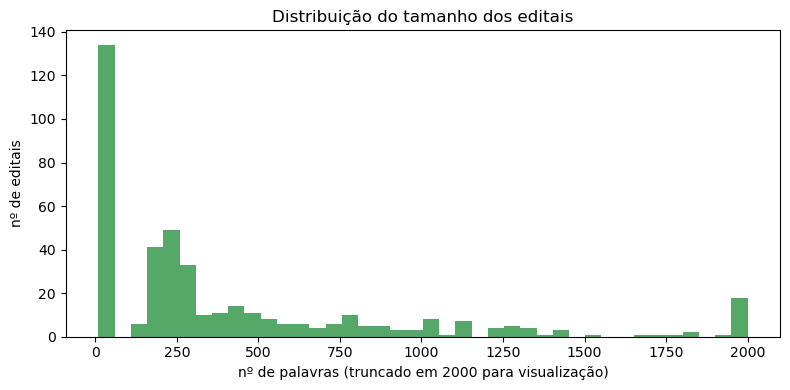

In [4]:
word_counts = [len((r.get("texto") or "").split()) for r in records]
word_counts_sorted = sorted(word_counts)
n = len(word_counts_sorted)
mediana = word_counts_sorted[n // 2]
print(f"min={min(word_counts)}  mediana={mediana}  max={max(word_counts)}")
print(f"acima de 512 palavras: {sum(1 for w in word_counts if w > 512)} editais "
      f"(relevante para o truncamento do BERT em 512 tokens)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([min(w, 2000) for w in word_counts], bins=40, color="#55A868")
ax.set_xlabel("nº de palavras (truncado em 2000 para visualização)")
ax.set_ylabel("nº de editais")
ax.set_title("Distribuição do tamanho dos editais")
fig.tight_layout()
fig.savefig(FIGURES / "eda_tamanho_texto.png", dpi=120)
plt.show()

## 4. Valor homologado por área

área                    n c/ valor         soma (R$)    mediana (R$)
Saude                          112       268,270,696         482,304
Saneamento                      49       147,829,530         634,456
Seguranca                       58        32,869,712          53,600
Educacao                        17       161,493,797       5,370,882
Infraestrutura/Obras            24        60,634,710         199,900
Administracao/Outros           163       126,154,991          20,800


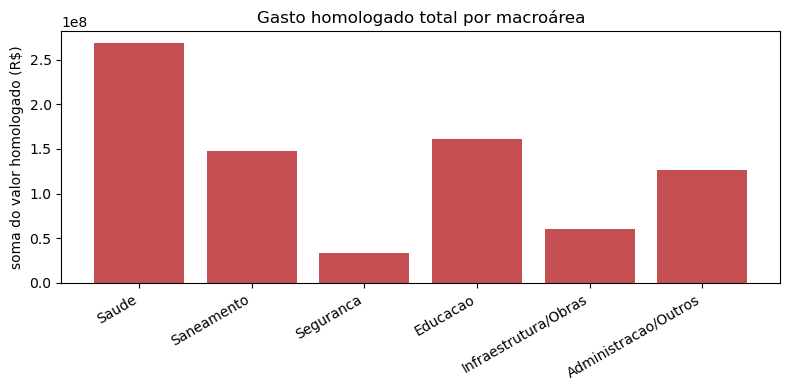

In [5]:
def parse_valor(v: str) -> float | None:
    """Converte 'R$ 1.234,56' (formato BR) para float; None se não numérico."""
    if not v:
        return None
    s = str(v).replace("R$", "").strip().replace(".", "").replace(",", ".")
    try:
        return float(s)
    except ValueError:
        return None

por_area = {a: [] for a in AREAS}
for r in records:
    val = parse_valor(r.get("total_homologado"))
    if val is not None and val > 0:
        por_area[r["area"]].append(val)

print(f"{'área':<24}{'n c/ valor':>10}{'soma (R$)':>18}{'mediana (R$)':>16}")
for a in AREAS:
    vals = sorted(por_area[a])
    if vals:
        soma = sum(vals)
        med = vals[len(vals) // 2]
        print(f"{a:<24}{len(vals):>10}{soma:>18,.0f}{med:>16,.0f}")
    else:
        print(f"{a:<24}{0:>10}{'-':>18}{'-':>16}")

somas = [sum(por_area[a]) for a in AREAS]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(AREAS, somas, color="#C44E52")
ax.set_ylabel("soma do valor homologado (R$)")
ax.set_title("Gasto homologado total por macroárea")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
fig.savefig(FIGURES / "eda_valor_por_area.png", dpi=120)
plt.show()

## 5. Vazamento de label: o órgão aparece no texto?

O label vem do órgão. Se o **nome do órgão** estiver dentro do `texto`, o classificador
pode "colar" em vez de aprender o conteúdo. Medimos quantos editais contêm uma das
palavras-chave da sua própria área no `texto` vs no `objeto_html`.

In [6]:
from src.preprocess.labels import AREA_KEYWORDS

kw_by_area = dict(AREA_KEYWORDS)  # área -> tuple de palavras-chave

def contem_keyword(texto: str, area: str) -> bool:
    kws = kw_by_area.get(area)
    if not kws:
        return False  # Administração/Outros não tem palavra-chave própria
    alvo = normalize(texto)
    return any(kw in alvo for kw in kws)

com_kw = [r for r in records if r["area"] in kw_by_area]
vaz_texto = sum(contem_keyword(r.get("texto", ""), r["area"]) for r in com_kw)
vaz_obj = sum(contem_keyword(r.get("objeto_html", ""), r["area"]) for r in com_kw)
base = len(com_kw)
print(f"Editais de áreas com palavra-chave: {base}")
print(f"  palavra-chave da área aparece em 'texto'      : {vaz_texto}/{base} ({vaz_texto/base:.0%})")
print(f"  palavra-chave da área aparece em 'objeto_html': {vaz_obj}/{base} ({vaz_obj/base:.0%})")
print()
print("→ Por isso usamos objeto_html como entrada honesta (ver guia §6.1).")

Editais de áreas com palavra-chave: 260
  palavra-chave da área aparece em 'texto'      : 252/260 (97%)
  palavra-chave da área aparece em 'objeto_html': 128/260 (49%)

→ Por isso usamos objeto_html como entrada honesta (ver guia §6.1).


## Conclusões da EDA

- **Desbalanceamento forte** entre areas macros → usar `class_weight`, reportar F1 por classe.
- Boa parte dos editais passa de **512 palavras** → BERTimbau truncará; considerar isso.
- O **gasto** concentra-se em poucas áreas (Saúde/Saneamento) — insight para a apresentação.
- **Vazamento confirmado**: o órgão aparece no `texto` com frequência muito maior que no
  `objeto_html`, justificando a escolha de entrada da classificação.